CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Width: 8487  Height: 14104
Minimum Elevation: -35.0
Maximum Elevation: 2523.0


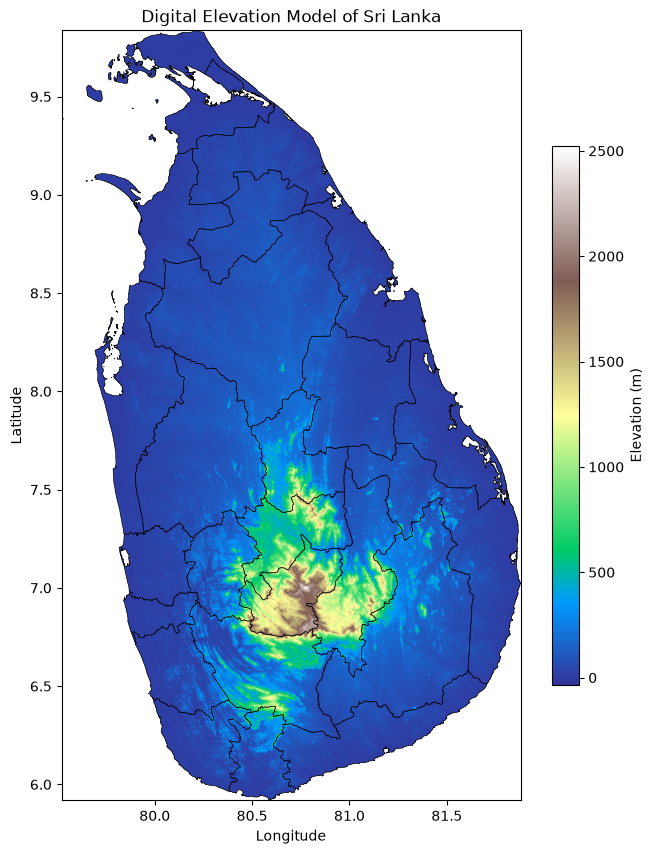

In [2]:
import os, gzip, shutil, urllib.request, urllib.error
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

DEM_FILE = "SriLanka_DEM.tif"

# ---------- 1. Download + mosaic SRTM tiles (only if DEM file is missing) ----------
def download_dem(out_file):
    os.makedirs("hgt_tiles", exist_ok=True)
    paths = []
    for lat in range(5, 10):          # N05 ... N09
        for lon in range(79, 82):     # E079 ... E081
            name = f"N{lat:02d}E{lon:03d}"
            hgt = f"hgt_tiles/{name}.hgt"
            if not os.path.exists(hgt):
                url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/N{lat:02d}/{name}.hgt.gz"
                try:
                    gz_file, _ = urllib.request.urlretrieve(url, hgt + ".gz")
                except urllib.error.HTTPError:
                    continue          # ocean-only tile, no data
                with gzip.open(gz_file, "rb") as f_in, open(hgt, "wb") as f_out:
                    shutil.copyfileobj(f_in, f_out)
                os.remove(gz_file)
            paths.append(hgt)

    srcs = [rasterio.open(p) for p in paths]
    mosaic, transform = merge(srcs)
    profile = srcs[0].profile.copy()
    profile.update(driver="GTiff", height=mosaic.shape[1], width=mosaic.shape[2],
                   transform=transform, count=1, nodata=-32768, compress="lzw")
    for s in srcs:
        s.close()
    with rasterio.open(out_file, "w", **profile) as dst:
        dst.write(mosaic[0], 1)
    print("DEM saved:", out_file)

if not os.path.exists(DEM_FILE):
    download_dem(DEM_FILE)

# ---------- 2. Load DEM and boundaries ----------
dem = rasterio.open(DEM_FILE)
country = gpd.read_file("gadm41_LKA_0.shp").to_crs(dem.crs)
districts = gpd.read_file("gadm41_LKA_1.shp").to_crs(dem.crs)

# ---------- 3. Clip DEM to Sri Lanka ----------
nodata = dem.nodata if dem.nodata is not None else -32768
elev, transform = mask(dem, country.geometry, crop=True, nodata=nodata)
elev = elev[0].astype("float32")
elev_masked = np.ma.masked_where((elev == nodata) | (elev < -100), elev)

print("CRS:", dem.crs)
print("Resolution:", dem.res)
print("Width:", elev.shape[1], " Height:", elev.shape[0])
print("Minimum Elevation:", elev_masked.min())
print("Maximum Elevation:", elev_masked.max())

# ---------- 4. Extent ----------
left, top = transform * (0, 0)
right, bottom = transform * (elev.shape[1], elev.shape[0])
extent = [left, right, bottom, top]

# ---------- 5. Plot ----------
fig, ax = plt.subplots(figsize=(8, 10))
img = ax.imshow(elev_masked, cmap="terrain", extent=extent)
districts.boundary.plot(ax=ax, color="black", linewidth=0.4)   # remove if not wanted

plt.colorbar(img, ax=ax, label="Elevation (m)", shrink=0.7)
ax.set_title("Digital Elevation Model of Sri Lanka")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.savefig("DEM_SriLanka.png", dpi=600, bbox_inches="tight")
plt.show()

Minimum Slope: 0.0
Maximum Slope: 80.194145
Mean Slope: 6.097621904812961


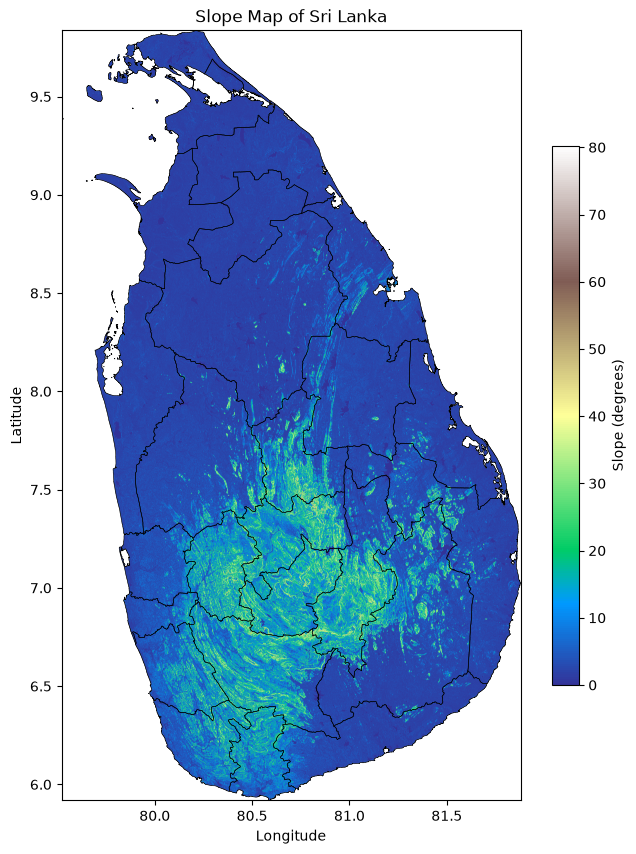

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Elevation as a normal array (sea / outside = NaN)
elevation = elev_masked.filled(np.nan).astype("float32")

# 2. Pixel size in meters (DEM is in degrees)
res_x, res_y = abs(transform.a), abs(transform.e)          # degrees
mid_lat = np.deg2rad((extent[2] + extent[3]) / 2)           # mean latitude of Sri Lanka
cell_y = res_y * 111320                                     # meters per pixel (north-south)
cell_x = res_x * 111320 * np.cos(mid_lat)                   # meters per pixel (east-west)

# 3. Slope
dy, dx = np.gradient(elevation, cell_y, cell_x)
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
slope = np.ma.masked_invalid(slope)

print("Minimum Slope:", slope.min())
print("Maximum Slope:", slope.max())
print("Mean Slope:", slope.mean())

# 4. Plot
fig, ax = plt.subplots(figsize=(8, 10))

img = ax.imshow(slope, cmap="terrain", extent=extent)
districts.boundary.plot(ax=ax, color="black", linewidth=0.4)   # remove if not wanted

plt.colorbar(img, ax=ax, label="Slope (degrees)", shrink=0.7)
ax.set_title("Slope Map of Sri Lanka")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.savefig("Slope_SriLanka.png", dpi=600, bbox_inches="tight")
plt.show()

CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Width: 8487  Height: 14104
Minimum Elevation: -35.0
Maximum Elevation: 2523.0


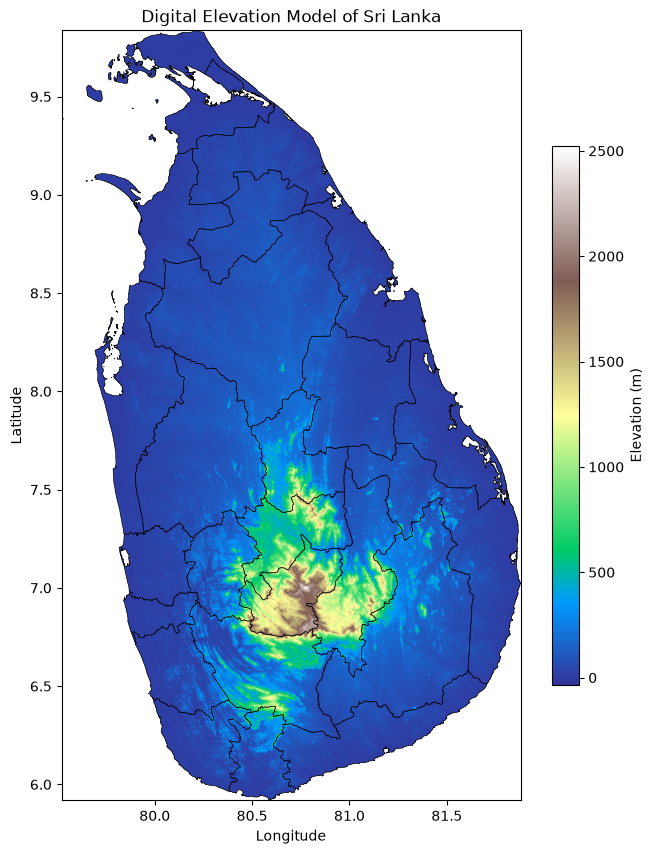

In [4]:
import os, gzip, shutil, urllib.request, urllib.error
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

DEM_FILE = "SriLanka_DEM.tif"

# ---------- 1. Download and mosaic SRTM tiles (only if the DEM is missing) ----------
def download_dem(out_file):
    os.makedirs("hgt_tiles", exist_ok=True)
    paths = []
    for lat in range(5, 10):          # N05 to N09
        for lon in range(79, 82):     # E079 to E081
            name = f"N{lat:02d}E{lon:03d}"
            hgt = f"hgt_tiles/{name}.hgt"
            if not os.path.exists(hgt):
                url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/N{lat:02d}/{name}.hgt.gz"
                try:
                    gz_file, _ = urllib.request.urlretrieve(url, hgt + ".gz")
                except urllib.error.HTTPError:
                    continue          # ocean-only tile
                with gzip.open(gz_file, "rb") as f_in, open(hgt, "wb") as f_out:
                    shutil.copyfileobj(f_in, f_out)
                os.remove(gz_file)
            paths.append(hgt)

    srcs = [rasterio.open(p) for p in paths]
    mosaic, transform = merge(srcs)
    profile = srcs[0].profile.copy()
    profile.update(driver="GTiff", height=mosaic.shape[1], width=mosaic.shape[2],
                   transform=transform, count=1, nodata=-32768, compress="lzw")
    for s in srcs:
        s.close()
    with rasterio.open(out_file, "w", **profile) as dst:
        dst.write(mosaic[0], 1)
    print("DEM saved:", out_file)

if not os.path.exists(DEM_FILE):
    download_dem(DEM_FILE)

# ---------- 2. Load DEM and boundaries ----------
dem = rasterio.open(DEM_FILE)
country = gpd.read_file("gadm41_LKA_0.shp").to_crs(dem.crs)
districts = gpd.read_file("gadm41_LKA_1.shp").to_crs(dem.crs)

# ---------- 3. Clip DEM to Sri Lanka ----------
nodata = dem.nodata if dem.nodata is not None else -32768
elev, transform = mask(dem, country.geometry, crop=True, nodata=nodata)
elev = elev[0].astype("float32")
elev_masked = np.ma.masked_where((elev == nodata) | (elev < -100), elev)

print("CRS:", dem.crs)
print("Resolution:", dem.res)
print("Width:", elev.shape[1], " Height:", elev.shape[0])
print("Minimum Elevation:", elev_masked.min())
print("Maximum Elevation:", elev_masked.max())

# ---------- 4. Extent ----------
left, top = transform * (0, 0)
right, bottom = transform * (elev.shape[1], elev.shape[0])
extent = [left, right, bottom, top]

# ---------- 5. Plot ----------
fig, ax = plt.subplots(figsize=(8, 10))
img = ax.imshow(elev_masked, cmap="terrain", extent=extent)
districts.boundary.plot(ax=ax, color="black", linewidth=0.4)   # remove if not wanted

plt.colorbar(img, ax=ax, label="Elevation (m)", shrink=0.7)
ax.set_title("Digital Elevation Model of Sri Lanka")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.savefig("DEM_SriLanka.png", dpi=600, bbox_inches="tight")
plt.show()

Minimum Slope: 0.0
Maximum Slope: 80.19
Mean Slope: 6.1


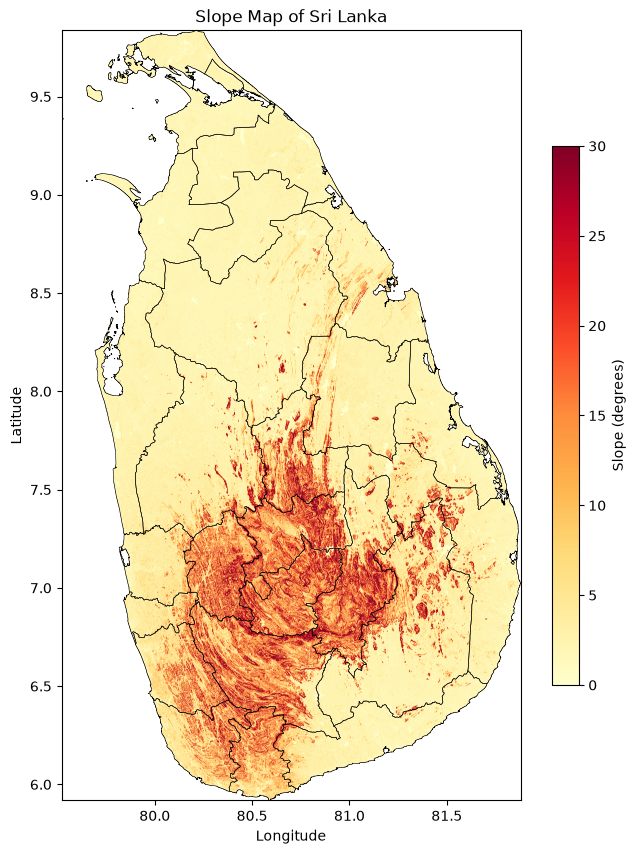

In [5]:
import os, gzip, shutil, urllib.request, urllib.error
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

DEM_FILE = "SriLanka_DEM.tif"

# ---------- 1. Download and mosaic SRTM tiles (only if the DEM is missing) ----------
def download_dem(out_file):
    os.makedirs("hgt_tiles", exist_ok=True)
    paths = []
    for lat in range(5, 10):          # N05 to N09
        for lon in range(79, 82):     # E079 to E081
            name = f"N{lat:02d}E{lon:03d}"
            hgt = f"hgt_tiles/{name}.hgt"
            if not os.path.exists(hgt):
                url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/N{lat:02d}/{name}.hgt.gz"
                try:
                    gz_file, _ = urllib.request.urlretrieve(url, hgt + ".gz")
                except urllib.error.HTTPError:
                    continue          # ocean-only tile
                with gzip.open(gz_file, "rb") as f_in, open(hgt, "wb") as f_out:
                    shutil.copyfileobj(f_in, f_out)
                os.remove(gz_file)
            paths.append(hgt)

    srcs = [rasterio.open(p) for p in paths]
    mosaic, transform = merge(srcs)
    profile = srcs[0].profile.copy()
    profile.update(driver="GTiff", height=mosaic.shape[1], width=mosaic.shape[2],
                   transform=transform, count=1, nodata=-32768, compress="lzw")
    for s in srcs:
        s.close()
    with rasterio.open(out_file, "w", **profile) as dst:
        dst.write(mosaic[0], 1)
    print("DEM saved:", out_file)

if not os.path.exists(DEM_FILE):
    download_dem(DEM_FILE)

# ---------- 2. Load DEM and boundaries ----------
dem = rasterio.open(DEM_FILE)
country = gpd.read_file("gadm41_LKA_0.shp").to_crs(dem.crs)
districts = gpd.read_file("gadm41_LKA_1.shp").to_crs(dem.crs)

# ---------- 3. Clip DEM to Sri Lanka ----------
nodata = dem.nodata if dem.nodata is not None else -32768
elev, transform = mask(dem, country.geometry, crop=True, nodata=nodata)
elev = elev[0].astype("float32")
elev_masked = np.ma.masked_where((elev == nodata) | (elev < -100), elev)

left, top = transform * (0, 0)
right, bottom = transform * (elev.shape[1], elev.shape[0])
extent = [left, right, bottom, top]

# ---------- 4. Calculate slope ----------
elevation = elev_masked.filled(np.nan).astype("float32")

res_x, res_y = abs(transform.a), abs(transform.e)      # pixel size in degrees
mid_lat = np.deg2rad((bottom + top) / 2)
cell_y = res_y * 111320                                 # meters per pixel (north-south)
cell_x = res_x * 111320 * np.cos(mid_lat)               # meters per pixel (east-west)

dy, dx = np.gradient(elevation, cell_y, cell_x)
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
slope = np.ma.masked_invalid(slope)

print("Minimum Slope:", round(float(slope.min()), 2))
print("Maximum Slope:", round(float(slope.max()), 2))
print("Mean Slope:", round(float(slope.mean()), 2))

# ---------- 5. Plot ----------
fig, ax = plt.subplots(figsize=(8, 10))
img = ax.imshow(slope, cmap="YlOrRd", extent=extent, vmin=0, vmax=30)
districts.boundary.plot(ax=ax, color="black", linewidth=0.4)   # remove if not wanted

plt.colorbar(img, ax=ax, label="Slope (degrees)", shrink=0.7)
ax.set_title("Slope Map of Sri Lanka")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.savefig("Slope_SriLanka.png", dpi=600, bbox_inches="tight")
plt.show()

Flat area (slope < 1 deg): 14.2%


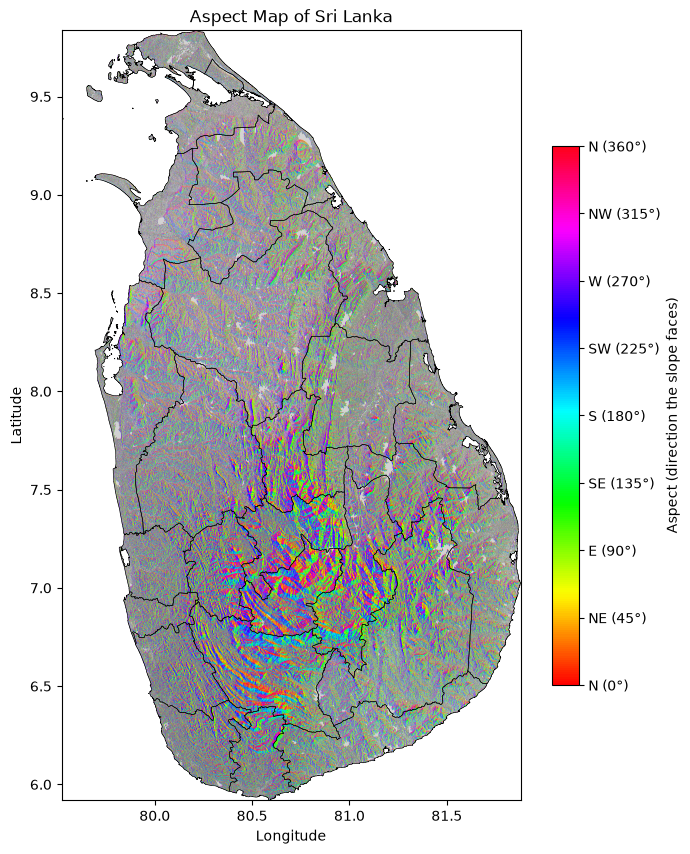

In [6]:
import os, gzip, shutil, urllib.request, urllib.error
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

DEM_FILE = "SriLanka_DEM.tif"

# ---------- 1. Download and mosaic SRTM tiles (only if the DEM is missing) ----------
def download_dem(out_file):
    os.makedirs("hgt_tiles", exist_ok=True)
    paths = []
    for lat in range(5, 10):          # N05 to N09
        for lon in range(79, 82):     # E079 to E081
            name = f"N{lat:02d}E{lon:03d}"
            hgt = f"hgt_tiles/{name}.hgt"
            if not os.path.exists(hgt):
                url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/N{lat:02d}/{name}.hgt.gz"
                try:
                    gz_file, _ = urllib.request.urlretrieve(url, hgt + ".gz")
                except urllib.error.HTTPError:
                    continue          # ocean-only tile
                with gzip.open(gz_file, "rb") as f_in, open(hgt, "wb") as f_out:
                    shutil.copyfileobj(f_in, f_out)
                os.remove(gz_file)
            paths.append(hgt)

    srcs = [rasterio.open(p) for p in paths]
    mosaic, transform = merge(srcs)
    profile = srcs[0].profile.copy()
    profile.update(driver="GTiff", height=mosaic.shape[1], width=mosaic.shape[2],
                   transform=transform, count=1, nodata=-32768, compress="lzw")
    for s in srcs:
        s.close()
    with rasterio.open(out_file, "w", **profile) as dst:
        dst.write(mosaic[0], 1)
    print("DEM saved:", out_file)

if not os.path.exists(DEM_FILE):
    download_dem(DEM_FILE)

# ---------- 2. Load DEM and boundaries ----------
dem = rasterio.open(DEM_FILE)
country = gpd.read_file("gadm41_LKA_0.shp").to_crs(dem.crs)
districts = gpd.read_file("gadm41_LKA_1.shp").to_crs(dem.crs)

# ---------- 3. Clip DEM to Sri Lanka ----------
nodata = dem.nodata if dem.nodata is not None else -32768
elev, transform = mask(dem, country.geometry, crop=True, nodata=nodata)
elev = elev[0].astype("float32")
elev_masked = np.ma.masked_where((elev == nodata) | (elev < -100), elev)

left, top = transform * (0, 0)
right, bottom = transform * (elev.shape[1], elev.shape[0])
extent = [left, right, bottom, top]

# ---------- 4. Calculate slope and aspect ----------
elevation = elev_masked.filled(np.nan).astype("float32")

res_x, res_y = abs(transform.a), abs(transform.e)      # pixel size in degrees
mid_lat = np.deg2rad((bottom + top) / 2)
cell_y = res_y * 111320                                 # meters per pixel (north-south)
cell_x = res_x * 111320 * np.cos(mid_lat)               # meters per pixel (east-west)

dy, dx = np.gradient(elevation, cell_y, cell_x)         # rows run north to south

slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

# Compass direction the slope faces (0 = North, 90 = East, 180 = South, 270 = West)
aspect = np.degrees(np.arctan2(-dx, dy)) % 360

inside = ~np.isnan(elevation)
flat = inside & (slope < 1)                             # nearly flat areas have no clear aspect
aspect = np.ma.masked_where(~inside | flat, aspect)

print("Flat area (slope < 1 deg): {:.1f}%".format(100 * flat.sum() / inside.sum()))

# ---------- 5. Plot ----------
fig, ax = plt.subplots(figsize=(8, 10))

# Flat areas in light grey
flat_layer = np.ma.masked_where(~flat, np.ones_like(elevation))
ax.imshow(flat_layer, cmap=ListedColormap(["lightgrey"]), extent=extent)

# Aspect in colors
img = ax.imshow(aspect, cmap="hsv", extent=extent, vmin=0, vmax=360)
districts.boundary.plot(ax=ax, color="black", linewidth=0.4)   # remove if not wanted

cbar = plt.colorbar(img, ax=ax, shrink=0.7, ticks=[0, 45, 90, 135, 180, 225, 270, 315, 360])
cbar.ax.set_yticklabels(["N (0°)", "NE (45°)", "E (90°)", "SE (135°)", "S (180°)",
                         "SW (225°)", "W (270°)", "NW (315°)", "N (360°)"])
cbar.set_label("Aspect (direction the slope faces)")

ax.set_title("Aspect Map of Sri Lanka")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
plt.savefig("Aspect_SriLanka.png", dpi=600, bbox_inches="tight")
plt.show()

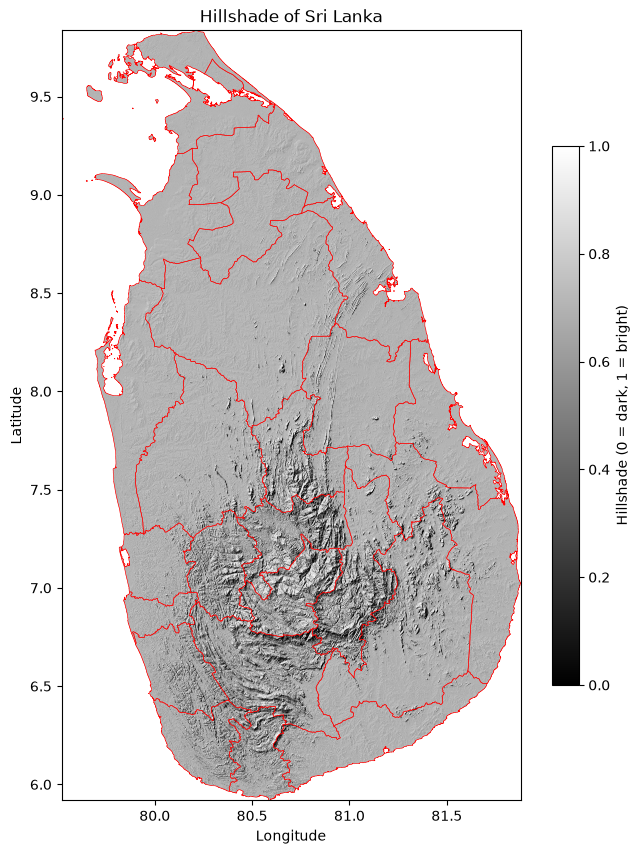

In [7]:
import os, gzip, shutil, urllib.request, urllib.error
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

DEM_FILE = "SriLanka_DEM.tif"

# ---------- 1. Download and mosaic SRTM tiles (only if the DEM is missing) ----------
def download_dem(out_file):
    os.makedirs("hgt_tiles", exist_ok=True)
    paths = []
    for lat in range(5, 10):          # N05 to N09
        for lon in range(79, 82):     # E079 to E081
            name = f"N{lat:02d}E{lon:03d}"
            hgt = f"hgt_tiles/{name}.hgt"
            if not os.path.exists(hgt):
                url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/N{lat:02d}/{name}.hgt.gz"
                try:
                    gz_file, _ = urllib.request.urlretrieve(url, hgt + ".gz")
                except urllib.error.HTTPError:
                    continue          # ocean-only tile
                with gzip.open(gz_file, "rb") as f_in, open(hgt, "wb") as f_out:
                    shutil.copyfileobj(f_in, f_out)
                os.remove(gz_file)
            paths.append(hgt)

    srcs = [rasterio.open(p) for p in paths]
    mosaic, transform = merge(srcs)
    profile = srcs[0].profile.copy()
    profile.update(driver="GTiff", height=mosaic.shape[1], width=mosaic.shape[2],
                   transform=transform, count=1, nodata=-32768, compress="lzw")
    for s in srcs:
        s.close()
    with rasterio.open(out_file, "w", **profile) as dst:
        dst.write(mosaic[0], 1)
    print("DEM saved:", out_file)

if not os.path.exists(DEM_FILE):
    download_dem(DEM_FILE)

# ---------- 2. Load DEM and boundaries ----------
dem = rasterio.open(DEM_FILE)
country = gpd.read_file("gadm41_LKA_0.shp").to_crs(dem.crs)
districts = gpd.read_file("gadm41_LKA_1.shp").to_crs(dem.crs)

# ---------- 3. Clip DEM to Sri Lanka ----------
nodata = dem.nodata if dem.nodata is not None else -32768
elev, transform = mask(dem, country.geometry, crop=True, nodata=nodata)
elev = elev[0].astype("float32")
elev_masked = np.ma.masked_where((elev == nodata) | (elev < -100), elev)

left, top = transform * (0, 0)
right, bottom = transform * (elev.shape[1], elev.shape[0])
extent = [left, right, bottom, top]

# ---------- 4. Calculate hillshade ----------
elevation = elev_masked.filled(np.nan).astype("float32")

res_x, res_y = abs(transform.a), abs(transform.e)      # pixel size in degrees
mid_lat = np.deg2rad((bottom + top) / 2)
cell_y = res_y * 111320                                 # meters per pixel (north-south)
cell_x = res_x * 111320 * np.cos(mid_lat)               # meters per pixel (east-west)

dy, dx = np.gradient(elevation, cell_y, cell_x)         # rows run north to south

azimuth = 315      # sun direction (315 = north-west)
altitude = 45      # sun height above the horizon in degrees
vert_exag = 3      # vertical exaggeration, makes the relief easier to see

dy *= vert_exag
dx *= vert_exag

slope = np.arctan(np.sqrt(dx**2 + dy**2))
aspect = np.arctan2(-dx, dy)

az = np.deg2rad(360 - azimuth + 90)
alt = np.deg2rad(altitude)

hillshade = (np.sin(alt) * np.cos(slope) +
             np.cos(alt) * np.sin(slope) * np.cos(az - (np.pi / 2 - aspect)))
hillshade = np.clip(hillshade, 0, 1)
hillshade = np.ma.masked_invalid(hillshade)

# ---------- 5. Plot ----------
fig, ax = plt.subplots(figsize=(8, 10))
img = ax.imshow(hillshade, cmap="gray", extent=extent, vmin=0, vmax=1)
districts.boundary.plot(ax=ax, color="red", linewidth=0.4)   # remove if not wanted

plt.colorbar(img, ax=ax, label="Hillshade (0 = dark, 1 = bright)", shrink=0.7)
ax.set_title("Hillshade of Sri Lanka")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
plt.savefig("Hillshade_SriLanka.png", dpi=600, bbox_inches="tight")
plt.show()

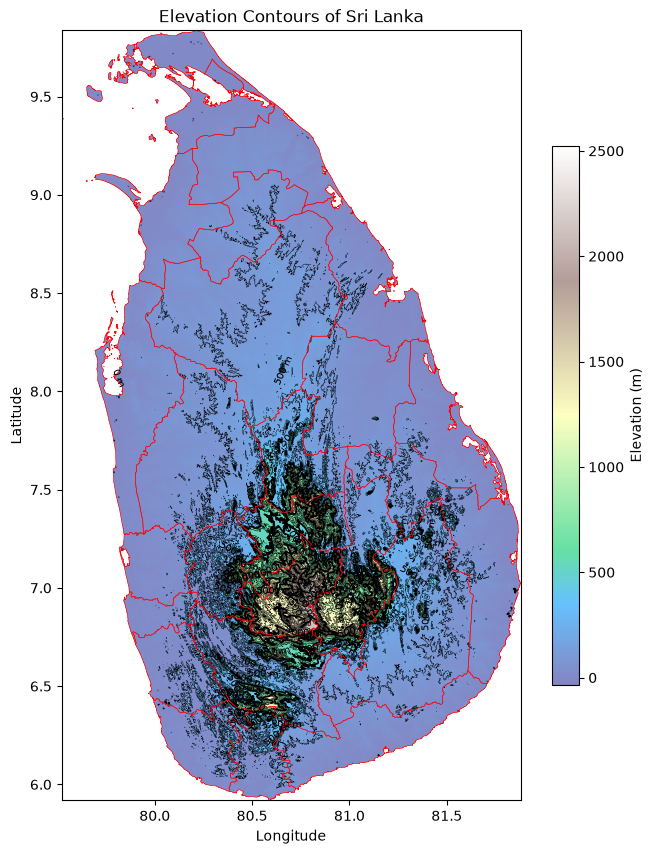

In [1]:
import os, gzip, shutil, urllib.request, urllib.error
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

DEM_FILE = "SriLanka_DEM.tif"

# ---------- 1. Download and mosaic SRTM tiles (only if the DEM is missing) ----------
def download_dem(out_file):
    os.makedirs("hgt_tiles", exist_ok=True)
    paths = []
    for lat in range(5, 10):          # N05 to N09
        for lon in range(79, 82):     # E079 to E081
            name = f"N{lat:02d}E{lon:03d}"
            hgt = f"hgt_tiles/{name}.hgt"
            if not os.path.exists(hgt):
                url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/N{lat:02d}/{name}.hgt.gz"
                try:
                    gz_file, _ = urllib.request.urlretrieve(url, hgt + ".gz")
                except urllib.error.HTTPError:
                    continue          # ocean-only tile
                with gzip.open(gz_file, "rb") as f_in, open(hgt, "wb") as f_out:
                    shutil.copyfileobj(f_in, f_out)
                os.remove(gz_file)
            paths.append(hgt)

    srcs = [rasterio.open(p) for p in paths]
    mosaic, transform = merge(srcs)
    profile = srcs[0].profile.copy()
    profile.update(driver="GTiff", height=mosaic.shape[1], width=mosaic.shape[2],
                   transform=transform, count=1, nodata=-32768, compress="lzw")
    for s in srcs:
        s.close()
    with rasterio.open(out_file, "w", **profile) as dst:
        dst.write(mosaic[0], 1)
    print("DEM saved:", out_file)

if not os.path.exists(DEM_FILE):
    download_dem(DEM_FILE)

# ---------- 2. Load DEM and boundaries ----------
dem = rasterio.open(DEM_FILE)
country = gpd.read_file("gadm41_LKA_0.shp").to_crs(dem.crs)
districts = gpd.read_file("gadm41_LKA_1.shp").to_crs(dem.crs)

# ---------- 3. Clip DEM to Sri Lanka ----------
nodata = dem.nodata if dem.nodata is not None else -32768
elev, transform = mask(dem, country.geometry, crop=True, nodata=nodata)
elev = elev[0].astype("float32")
elev_masked = np.ma.masked_where((elev == nodata) | (elev < -100), elev)

left, top = transform * (0, 0)
right, bottom = transform * (elev.shape[1], elev.shape[0])
extent = [left, right, bottom, top]

# ---------- 4. Smooth the elevation (NumPy only, no scipy) ----------
elevation = elev_masked.filled(np.nan).astype("float32")

def smooth_nan(arr, k=3):
    """Box-blur of radius k that ignores NaN (sea / outside) pixels."""
    valid = ~np.isnan(arr)
    a = np.where(valid, arr, 0).astype("float64")
    w = valid.astype("float64")
    a_p = np.pad(a, k, mode="constant")
    w_p = np.pad(w, k, mode="constant")
    sum_a = np.zeros_like(a)
    sum_w = np.zeros_like(w)
    rows, cols = arr.shape
    for dy in range(-k, k + 1):
        for dx in range(-k, k + 1):
            sum_a += a_p[k + dy:k + dy + rows, k + dx:k + dx + cols]
            sum_w += w_p[k + dy:k + dy + rows, k + dx:k + dx + cols]
    out = np.where(sum_w > 0, sum_a / np.maximum(sum_w, 1), np.nan)
    out[~valid] = np.nan
    return out

smooth = np.ma.masked_invalid(smooth_nan(elevation, k=3))

# Grid of coordinates for each pixel
lons = np.linspace(left, right, elevation.shape[1])
lats = np.linspace(top, bottom, elevation.shape[0])
X, Y = np.meshgrid(lons, lats)

interval = 100                                   # contour interval in meters
max_elev = float(np.nanmax(elevation))
levels = np.arange(0, max_elev + interval, interval)

# ---------- 5. Plot ----------
fig, ax = plt.subplots(figsize=(8, 10))

# Light elevation background
img = ax.imshow(elev_masked, cmap="terrain", extent=extent, alpha=0.6)

# Thin contour lines
ax.contour(X, Y, smooth, levels=levels, colors="black", linewidths=0.3)

# Bold lines every 500 m with labels
major_levels = np.arange(0, max_elev + 500, 500)
cs_major = ax.contour(X, Y, smooth, levels=major_levels, colors="black", linewidths=1.0)
ax.clabel(cs_major, fmt="%d m", fontsize=7)

districts.boundary.plot(ax=ax, color="red", linewidth=0.4)   # remove if not wanted

plt.colorbar(img, ax=ax, label="Elevation (m)", shrink=0.7)
ax.set_title("Elevation Contours of Sri Lanka")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
plt.savefig("Contours_SriLanka.png", dpi=600, bbox_inches="tight")
plt.show()

CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Width: 8487  Height: 14104
Minimum Elevation: -35.0
Maximum Elevation: 2523.0


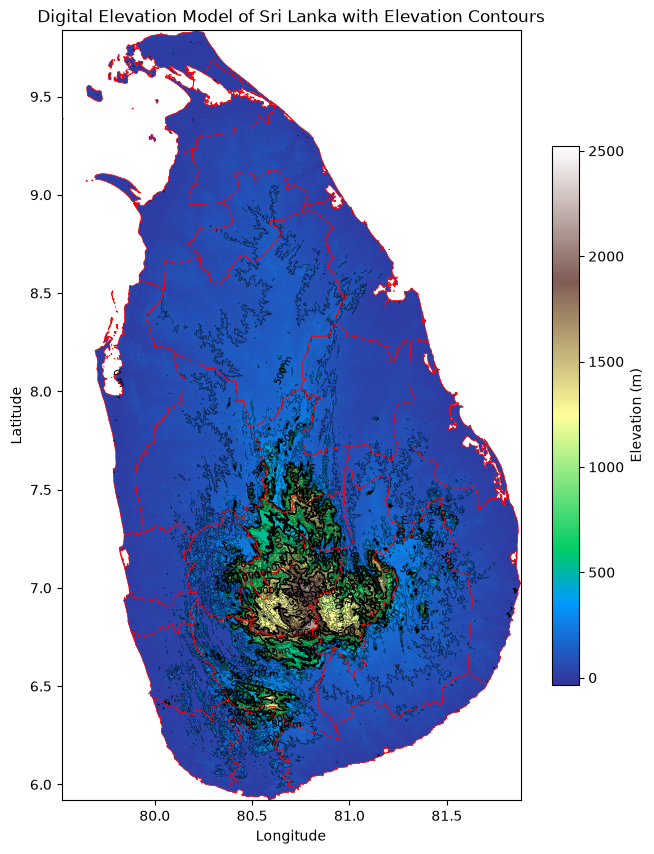

In [2]:
import os, gzip, shutil, urllib.request, urllib.error
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt

DEM_FILE = "SriLanka_DEM.tif"

# ---------- 1. Download and mosaic SRTM tiles (only if the DEM is missing) ----------
def download_dem(out_file):
    os.makedirs("hgt_tiles", exist_ok=True)
    paths = []
    for lat in range(5, 10):          # N05 to N09
        for lon in range(79, 82):     # E079 to E081
            name = f"N{lat:02d}E{lon:03d}"
            hgt = f"hgt_tiles/{name}.hgt"
            if not os.path.exists(hgt):
                url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/N{lat:02d}/{name}.hgt.gz"
                try:
                    gz_file, _ = urllib.request.urlretrieve(url, hgt + ".gz")
                except urllib.error.HTTPError:
                    continue          # ocean-only tile
                with gzip.open(gz_file, "rb") as f_in, open(hgt, "wb") as f_out:
                    shutil.copyfileobj(f_in, f_out)
                os.remove(gz_file)
            paths.append(hgt)

    srcs = [rasterio.open(p) for p in paths]
    mosaic, transform = merge(srcs)
    profile = srcs[0].profile.copy()
    profile.update(driver="GTiff", height=mosaic.shape[1], width=mosaic.shape[2],
                   transform=transform, count=1, nodata=-32768, compress="lzw")
    for s in srcs:
        s.close()
    with rasterio.open(out_file, "w", **profile) as dst:
        dst.write(mosaic[0], 1)
    print("DEM saved:", out_file)

if not os.path.exists(DEM_FILE):
    download_dem(DEM_FILE)

# ---------- 2. Load DEM and boundaries ----------
dem = rasterio.open(DEM_FILE)
country = gpd.read_file("gadm41_LKA_0.shp").to_crs(dem.crs)
districts = gpd.read_file("gadm41_LKA_1.shp").to_crs(dem.crs)

# ---------- 3. Clip DEM to Sri Lanka ----------
nodata = dem.nodata if dem.nodata is not None else -32768
elev, transform = mask(dem, country.geometry, crop=True, nodata=nodata)
elev = elev[0].astype("float32")
elev_masked = np.ma.masked_where((elev == nodata) | (elev < -100), elev)

print("CRS:", dem.crs)
print("Resolution:", dem.res)
print("Width:", elev.shape[1], " Height:", elev.shape[0])
print("Minimum Elevation:", elev_masked.min())
print("Maximum Elevation:", elev_masked.max())

left, top = transform * (0, 0)
right, bottom = transform * (elev.shape[1], elev.shape[0])
extent = [left, right, bottom, top]

# ---------- 4. Smooth the elevation for clean contour lines (NumPy only) ----------
elevation = elev_masked.filled(np.nan).astype("float32")

def smooth_nan(arr, k=3):
    """Box-blur of radius k that ignores NaN (sea / outside) pixels."""
    valid = ~np.isnan(arr)
    a = np.where(valid, arr, 0).astype("float64")
    w = valid.astype("float64")
    a_p = np.pad(a, k, mode="constant")
    w_p = np.pad(w, k, mode="constant")
    sum_a = np.zeros_like(a)
    sum_w = np.zeros_like(w)
    rows, cols = arr.shape
    for dy in range(-k, k + 1):
        for dx in range(-k, k + 1):
            sum_a += a_p[k + dy:k + dy + rows, k + dx:k + dx + cols]
            sum_w += w_p[k + dy:k + dy + rows, k + dx:k + dx + cols]
    out = np.where(sum_w > 0, sum_a / np.maximum(sum_w, 1), np.nan)
    out[~valid] = np.nan
    return out

smooth = np.ma.masked_invalid(smooth_nan(elevation, k=3))

lons = np.linspace(left, right, elevation.shape[1])
lats = np.linspace(top, bottom, elevation.shape[0])
X, Y = np.meshgrid(lons, lats)

interval = 100                                   # contour interval in meters
max_elev = float(np.nanmax(elevation))
levels = np.arange(0, max_elev + interval, interval)
major_levels = np.arange(0, max_elev + 500, 500)

# ---------- 5. Plot DEM with contours ----------
fig, ax = plt.subplots(figsize=(8, 10))

# DEM in full color
img = ax.imshow(elev_masked, cmap="terrain", extent=extent)

# Thin contour lines every 100 m
ax.contour(X, Y, smooth, levels=levels, colors="black", linewidths=0.3, alpha=0.7)

# Bold labelled lines every 500 m
cs_major = ax.contour(X, Y, smooth, levels=major_levels, colors="black", linewidths=0.9)
ax.clabel(cs_major, fmt="%d m", fontsize=7)

districts.boundary.plot(ax=ax, color="red", linewidth=0.4)   # remove if not wanted

plt.colorbar(img, ax=ax, label="Elevation (m)", shrink=0.7)
ax.set_title("Digital Elevation Model of Sri Lanka with Elevation Contours")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
plt.savefig("DEM_Contours_SriLanka.png", dpi=600, bbox_inches="tight")
plt.show()

In [3]:
import os, gzip, shutil, urllib.request, urllib.error
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

DISTRICT = "Ampara"
DEM_FILE = "SriLanka_DEM.tif"

# ---------- Download and mosaic SRTM tiles (only if the DEM is missing) ----------
def download_dem(out_file):
    os.makedirs("hgt_tiles", exist_ok=True)
    paths = []
    for lat in range(5, 10):
        for lon in range(79, 82):
            name = f"N{lat:02d}E{lon:03d}"
            hgt = f"hgt_tiles/{name}.hgt"
            if not os.path.exists(hgt):
                url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/N{lat:02d}/{name}.hgt.gz"
                try:
                    gz_file, _ = urllib.request.urlretrieve(url, hgt + ".gz")
                except urllib.error.HTTPError:
                    continue
                with gzip.open(gz_file, "rb") as f_in, open(hgt, "wb") as f_out:
                    shutil.copyfileobj(f_in, f_out)
                os.remove(gz_file)
            paths.append(hgt)
    srcs = [rasterio.open(p) for p in paths]
    mosaic, transform = merge(srcs)
    profile = srcs[0].profile.copy()
    profile.update(driver="GTiff", height=mosaic.shape[1], width=mosaic.shape[2],
                   transform=transform, count=1, nodata=-32768, compress="lzw")
    for s in srcs:
        s.close()
    with rasterio.open(out_file, "w", **profile) as dst:
        dst.write(mosaic[0], 1)
    print("DEM saved:", out_file)

if not os.path.exists(DEM_FILE):
    download_dem(DEM_FILE)

# ---------- Load DEM and select Ampara district ----------
dem = rasterio.open(DEM_FILE)
districts_all = gpd.read_file("gadm41_LKA_2.shp").to_crs(dem.crs)

ampara = districts_all[districts_all["NAME_2"].str.lower() == DISTRICT.lower()]
if ampara.empty:
    print("District not found. Available names:")
    print(sorted(districts_all["NAME_2"].unique()))
    raise SystemExit

# ---------- Clip DEM to Ampara ----------
nodata = dem.nodata if dem.nodata is not None else -32768
elev, transform = mask(dem, ampara.geometry, crop=True, nodata=nodata)
elev = elev[0].astype("float32")
elev_masked = np.ma.masked_where((elev == nodata) | (elev < -100), elev)
elevation = elev_masked.filled(np.nan).astype("float32")

left, top = transform * (0, 0)
right, bottom = transform * (elev.shape[1], elev.shape[0])
extent = [left, right, bottom, top]

print("CRS:", dem.crs)
print("Resolution:", dem.res)
print("Width:", elev.shape[1], " Height:", elev.shape[0])
print("Minimum Elevation:", elev_masked.min())
print("Maximum Elevation:", elev_masked.max())

# ---------- Pixel size in meters (used by slope, aspect, hillshade) ----------
res_x, res_y = abs(transform.a), abs(transform.e)
mid_lat = np.deg2rad((bottom + top) / 2)
cell_y = res_y * 111320
cell_x = res_x * 111320 * np.cos(mid_lat)

dy, dx = np.gradient(elevation, cell_y, cell_x)
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

# ---------- Smoothing for contours (NumPy only, no scipy) ----------
def smooth_nan(arr, k=3):
    valid = ~np.isnan(arr)
    a = np.where(valid, arr, 0).astype("float64")
    w = valid.astype("float64")
    a_p = np.pad(a, k, mode="constant")
    w_p = np.pad(w, k, mode="constant")
    sum_a = np.zeros_like(a)
    sum_w = np.zeros_like(w)
    rows, cols = arr.shape
    for i in range(-k, k + 1):
        for j in range(-k, k + 1):
            sum_a += a_p[k + i:k + i + rows, k + j:k + j + cols]
            sum_w += w_p[k + i:k + i + rows, k + j:k + j + cols]
    out = np.where(sum_w > 0, sum_a / np.maximum(sum_w, 1), np.nan)
    out[~valid] = np.nan
    return out

smooth = np.ma.masked_invalid(smooth_nan(elevation, k=3))

lons = np.linspace(left, right, elevation.shape[1])
lats = np.linspace(top, bottom, elevation.shape[0])
X, Y = np.meshgrid(lons, lats)

def finish(ax, title):
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

print("Setup done. Now run the map cells.")

CRS: EPSG:4326
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Width: 696  Height: 416
Minimum Elevation: 17.0
Maximum Elevation: 148.0
Setup done. Now run the map cells.


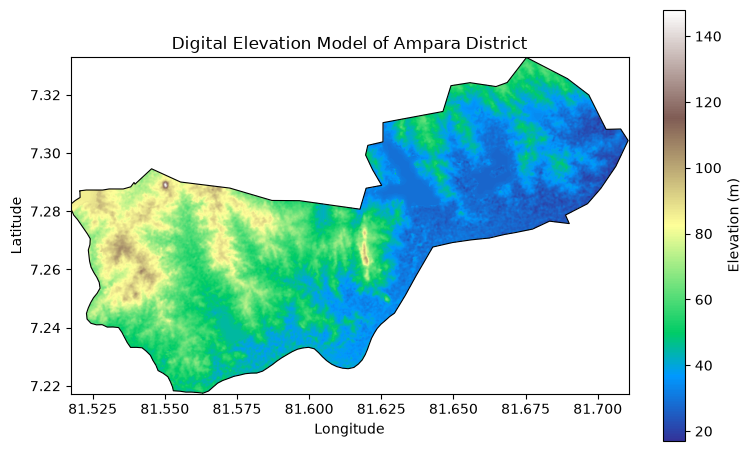

In [4]:
fig, ax = plt.subplots(figsize=(9, 8))
img = ax.imshow(elev_masked, cmap="terrain", extent=extent)
ampara.boundary.plot(ax=ax, color="black", linewidth=0.8)

plt.colorbar(img, ax=ax, label="Elevation (m)", shrink=0.7)
finish(ax, "Digital Elevation Model of Ampara District")
plt.savefig("DEM_Ampara.png", dpi=600, bbox_inches="tight")
plt.show()

Minimum Slope: 0.0
Maximum Slope: 29.32
Mean Slope: 2.86


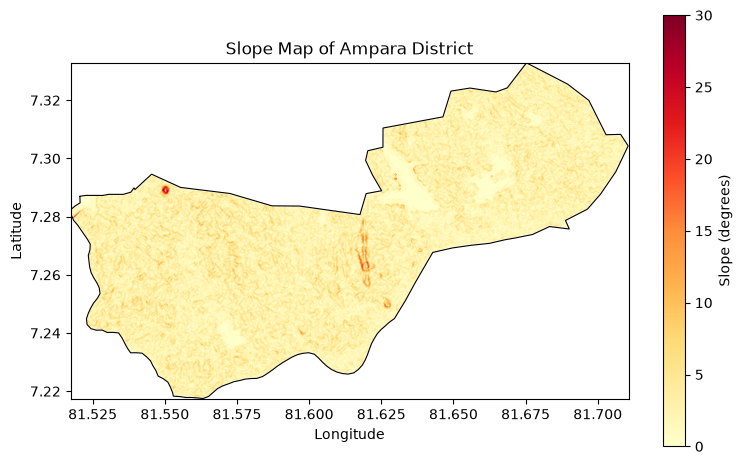

In [5]:
slope_m = np.ma.masked_invalid(slope)
print("Minimum Slope:", round(float(slope_m.min()), 2))
print("Maximum Slope:", round(float(slope_m.max()), 2))
print("Mean Slope:", round(float(slope_m.mean()), 2))

fig, ax = plt.subplots(figsize=(9, 8))
img = ax.imshow(slope_m, cmap="YlOrRd", extent=extent, vmin=0, vmax=30)
ampara.boundary.plot(ax=ax, color="black", linewidth=0.8)

plt.colorbar(img, ax=ax, label="Slope (degrees)", shrink=0.7)
finish(ax, "Slope Map of Ampara District")
plt.savefig("Slope_Ampara.png", dpi=600, bbox_inches="tight")
plt.show()

Flat area (slope < 1 deg): 15.9%


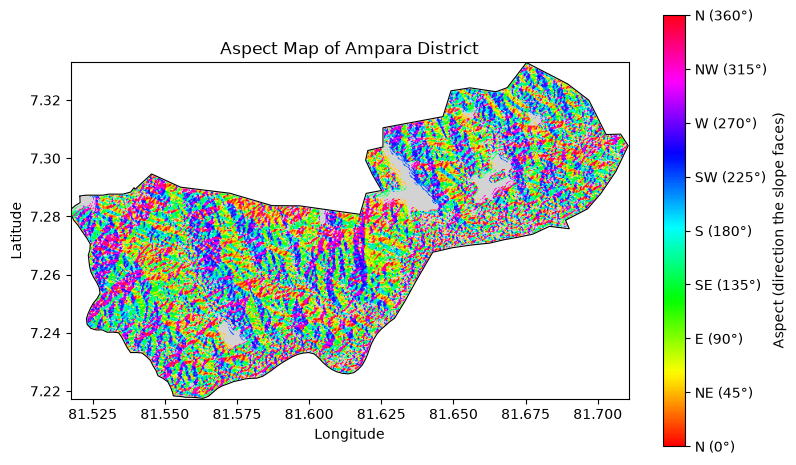

In [6]:
aspect = np.degrees(np.arctan2(-dx, dy)) % 360

inside = ~np.isnan(elevation)
flat = inside & (slope < 1)
aspect_m = np.ma.masked_where(~inside | flat, aspect)
print("Flat area (slope < 1 deg): {:.1f}%".format(100 * flat.sum() / inside.sum()))

fig, ax = plt.subplots(figsize=(9, 8))

flat_layer = np.ma.masked_where(~flat, np.ones_like(elevation))
ax.imshow(flat_layer, cmap=ListedColormap(["lightgrey"]), extent=extent)

img = ax.imshow(aspect_m, cmap="hsv", extent=extent, vmin=0, vmax=360)
ampara.boundary.plot(ax=ax, color="black", linewidth=0.8)

cbar = plt.colorbar(img, ax=ax, shrink=0.7, ticks=[0, 45, 90, 135, 180, 225, 270, 315, 360])
cbar.ax.set_yticklabels(["N (0°)", "NE (45°)", "E (90°)", "SE (135°)", "S (180°)",
                         "SW (225°)", "W (270°)", "NW (315°)", "N (360°)"])
cbar.set_label("Aspect (direction the slope faces)")

finish(ax, "Aspect Map of Ampara District")
plt.savefig("Aspect_Ampara.png", dpi=600, bbox_inches="tight")
plt.show()

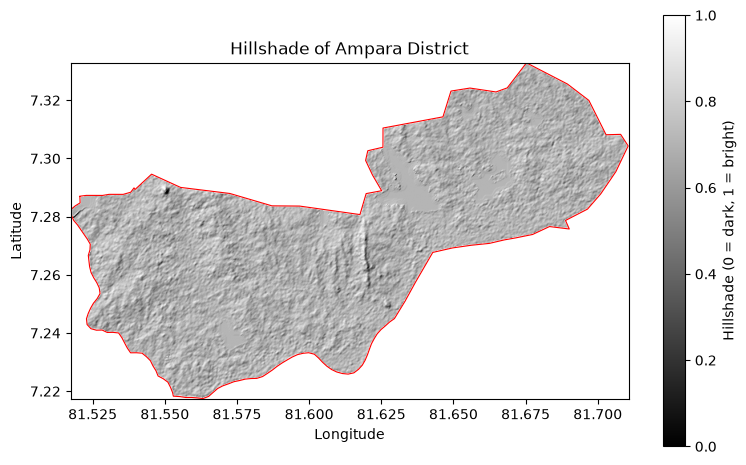

In [7]:
azimuth = 315      # sun direction (315 = north-west)
altitude = 45      # sun height in degrees
vert_exag = 3      # vertical exaggeration

dy_h, dx_h = dy * vert_exag, dx * vert_exag
slope_r = np.arctan(np.sqrt(dx_h**2 + dy_h**2))
aspect_r = np.arctan2(-dx_h, dy_h)

az = np.deg2rad(360 - azimuth + 90)
alt = np.deg2rad(altitude)

hillshade = (np.sin(alt) * np.cos(slope_r) +
             np.cos(alt) * np.sin(slope_r) * np.cos(az - (np.pi / 2 - aspect_r)))
hillshade = np.ma.masked_invalid(np.clip(hillshade, 0, 1))

fig, ax = plt.subplots(figsize=(9, 8))
img = ax.imshow(hillshade, cmap="gray", extent=extent, vmin=0, vmax=1)
ampara.boundary.plot(ax=ax, color="red", linewidth=0.8)

plt.colorbar(img, ax=ax, label="Hillshade (0 = dark, 1 = bright)", shrink=0.7)
finish(ax, "Hillshade of Ampara District")
plt.savefig("Hillshade_Ampara.png", dpi=600, bbox_inches="tight")
plt.show()

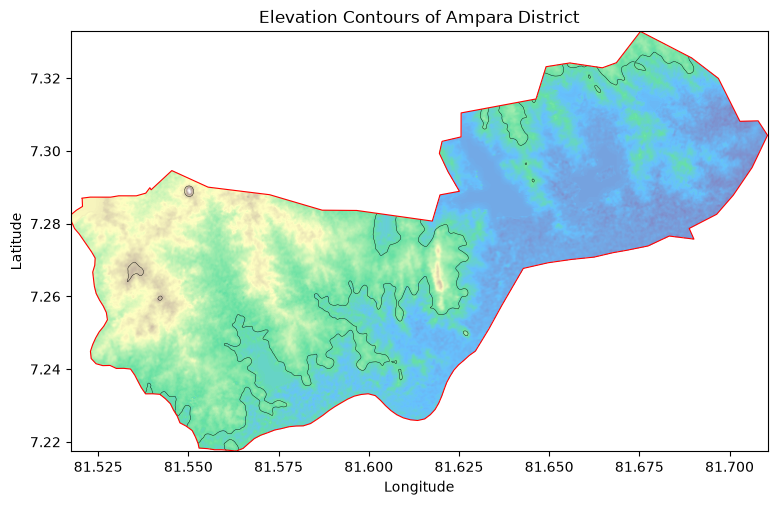

In [8]:
interval = 50                      # thin lines every 50 m
major = 200                        # bold labelled lines every 200 m
max_elev = float(np.nanmax(elevation))
levels = np.arange(0, max_elev + interval, interval)
major_levels = np.arange(0, max_elev + major, major)

fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(elev_masked, cmap="terrain", extent=extent, alpha=0.6)

ax.contour(X, Y, smooth, levels=levels, colors="black", linewidths=0.3)
cs_major = ax.contour(X, Y, smooth, levels=major_levels, colors="black", linewidths=1.0)
ax.clabel(cs_major, fmt="%d m", fontsize=7)

ampara.boundary.plot(ax=ax, color="red", linewidth=0.8)
finish(ax, "Elevation Contours of Ampara District")
plt.savefig("Contours_Ampara.png", dpi=600, bbox_inches="tight")
plt.show()

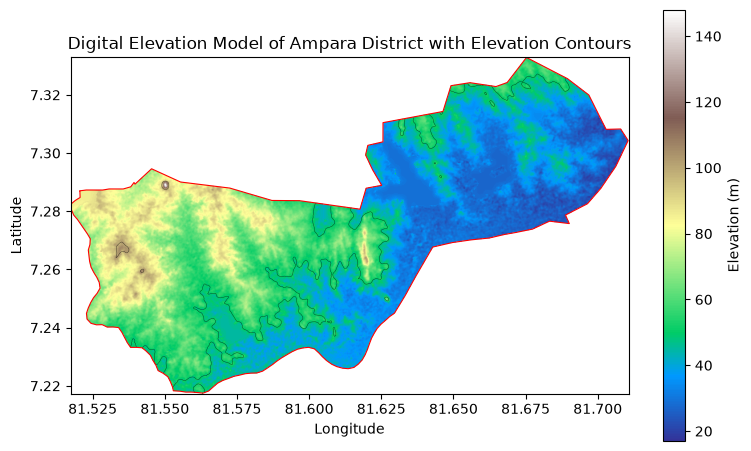

In [9]:
interval = 50
major = 200
max_elev = float(np.nanmax(elevation))
levels = np.arange(0, max_elev + interval, interval)
major_levels = np.arange(0, max_elev + major, major)

fig, ax = plt.subplots(figsize=(9, 8))
img = ax.imshow(elev_masked, cmap="terrain", extent=extent)

ax.contour(X, Y, smooth, levels=levels, colors="black", linewidths=0.3, alpha=0.7)
cs_major = ax.contour(X, Y, smooth, levels=major_levels, colors="black", linewidths=0.9)
ax.clabel(cs_major, fmt="%d m", fontsize=7)

ampara.boundary.plot(ax=ax, color="red", linewidth=0.8)

plt.colorbar(img, ax=ax, label="Elevation (m)", shrink=0.7)
finish(ax, "Digital Elevation Model of Ampara District with Elevation Contours")
plt.savefig("DEM_Contours_Ampara.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
import os, gzip, shutil, urllib.request, urllib.error
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

PROVINCE = "Eastern"
DEM_FILE = "SriLanka_DEM.tif"

# ---------- Download and mosaic SRTM tiles (only if the DEM is missing) ----------
def download_dem(out_file):
    os.makedirs("hgt_tiles", exist_ok=True)
    paths = []
    for lat in range(5, 10):
        for lon in range(79, 82):
            name = f"N{lat:02d}E{lon:03d}"
            hgt = f"hgt_tiles/{name}.hgt"
            if not os.path.exists(hgt):
                url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/N{lat:02d}/{name}.hgt.gz"
                try:
                    gz_file, _ = urllib.request.urlretrieve(url, hgt + ".gz")
                except urllib.error.HTTPError:
                    continue
                with gzip.open(gz_file, "rb") as f_in, open(hgt, "wb") as f_out:
                    shutil.copyfileobj(f_in, f_out)
                os.remove(gz_file)
            paths.append(hgt)
    srcs = [rasterio.open(p) for p in paths]
    mosaic, transform = merge(srcs)
    profile = srcs[0].profile.copy()
    profile.update(driver="GTiff", height=mosaic.shape[1], width=mosaic.shape[2],
                   transform=transform, count=1, nodata=-32768, compress="lzw")
    for s in srcs:
        s.close()
    with rasterio.open(out_file, "w", **profile) as dst:
        dst.write(mosaic[0], 1)
    print("DEM saved:", out_file)

if not os.path.exists(DEM_FILE):
    download_dem(DEM_FILE)

# ---------- Load DEM and select the Eastern Province ----------
dem = rasterio.open(DEM_FILE)
provinces_all = gpd.read_file("gadm41_LKA_1.shp").to_crs(dem.crs)

eastern = provinces_all[provinces_all["NAME_1"].str.lower() == PROVINCE.lower()]
if eastern.empty:
    print("Province not found. Available names:")
    print(sorted(provinces_all["NAME_1"].unique()))
    raise ValueError("Change PROVINCE to one of the names above.")

# District boundaries inside the province
districts_all = gpd.read_file("gadm41_LKA_2.shp").to_crs(dem.crs)
east_districts = gpd.clip(districts_all, eastern)

# ---------- Clip DEM to the Eastern Province ----------
nodata = dem.nodata if dem.nodata is not None else -32768
elev, transform = mask(dem, eastern.geometry, crop=True, nodata=nodata)
elev = elev[0].astype("float32")
elev_masked = np.ma.masked_where((elev == nodata) | (elev < -100), elev)
elevation = elev_masked.filled(np.nan).astype("float32")

left, top = transform * (0, 0)
right, bottom = transform * (elev.shape[1], elev.shape[0])
extent = [left, right, bottom, top]

print("CRS:", dem.crs)
print("Resolution:", dem.res)
print("Width:", elev.shape[1], " Height:", elev.shape[0])
print("Minimum Elevation:", elev_masked.min())
print("Maximum Elevation:", elev_masked.max())

# ---------- Pixel size in meters (used by slope, aspect, hillshade) ----------
res_x, res_y = abs(transform.a), abs(transform.e)
mid_lat = np.deg2rad((bottom + top) / 2)
cell_y = res_y * 111320
cell_x = res_x * 111320 * np.cos(mid_lat)

dy, dx = np.gradient(elevation, cell_y, cell_x)
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

# ---------- Smoothing for contours (NumPy only, no scipy) ----------
def smooth_nan(arr, k=3):
    is_nan = np.isnan(arr)
    valid = np.logical_not(is_nan)
    a = np.where(valid, arr, 0).astype("float64")
    w = valid.astype("float64")
    a_p = np.pad(a, k, mode="constant")
    w_p = np.pad(w, k, mode="constant")
    sum_a = np.zeros_like(a)
    sum_w = np.zeros_like(w)
    rows, cols = arr.shape
    for i in range(-k, k + 1):
        for j in range(-k, k + 1):
            sum_a += a_p[k + i:k + i + rows, k + j:k + j + cols]
            sum_w += w_p[k + i:k + i + rows, k + j:k + j + cols]
    out = np.where(sum_w > 0, sum_a / np.maximum(sum_w, 1), np.nan)
    out[is_nan] = np.nan
    return out

smooth = np.ma.masked_invalid(smooth_nan(elevation, k=3))

lons = np.linspace(left, right, elevation.shape[1])
lats = np.linspace(top, bottom, elevation.shape[0])
X, Y = np.meshgrid(lons, lats)

def draw_boundaries(ax, color="black"):
    east_districts.boundary.plot(ax=ax, color=color, linewidth=0.5, linestyle="--")  # districts
    eastern.boundary.plot(ax=ax, color=color, linewidth=1.2)                          # province

def finish(ax, title):
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

print("Setup done. Now run the map cells.")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 10))
img = ax.imshow(elev_masked, cmap="terrain", extent=extent)
draw_boundaries(ax, "black")

plt.colorbar(img, ax=ax, label="Elevation (m)", shrink=0.7)
finish(ax, "Digital Elevation Model of Eastern Province")
plt.savefig("DEM_Eastern.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
slope_m = np.ma.masked_invalid(slope)
print("Minimum Slope:", round(float(slope_m.min()), 2))
print("Maximum Slope:", round(float(slope_m.max()), 2))
print("Mean Slope:", round(float(slope_m.mean()), 2))

fig, ax = plt.subplots(figsize=(7, 10))
img = ax.imshow(slope_m, cmap="YlOrRd", extent=extent, vmin=0, vmax=30)
draw_boundaries(ax, "black")

plt.colorbar(img, ax=ax, label="Slope (degrees)", shrink=0.7)
finish(ax, "Slope Map of Eastern Province")
plt.savefig("Slope_Eastern.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
aspect = np.degrees(np.arctan2(-dx, dy)) % 360

outside = np.isnan(elevation)
flat = np.logical_and(np.logical_not(outside), slope < 1)
not_flat = np.logical_not(flat)
aspect_m = np.ma.masked_where(np.logical_or(outside, flat), aspect)

n_inside = np.logical_not(outside).sum()
print("Flat area (slope < 1 deg): {:.1f}%".format(100 * flat.sum() / n_inside))

fig, ax = plt.subplots(figsize=(7, 10))

flat_layer = np.ma.masked_where(not_flat, np.ones_like(elevation))
ax.imshow(flat_layer, cmap=ListedColormap(["lightgrey"]), extent=extent)

img = ax.imshow(aspect_m, cmap="hsv", extent=extent, vmin=0, vmax=360)
draw_boundaries(ax, "black")

cbar = plt.colorbar(img, ax=ax, shrink=0.7, ticks=[0, 45, 90, 135, 180, 225, 270, 315, 360])
cbar.ax.set_yticklabels(["N (0°)", "NE (45°)", "E (90°)", "SE (135°)", "S (180°)",
                         "SW (225°)", "W (270°)", "NW (315°)", "N (360°)"])
cbar.set_label("Aspect (direction the slope faces)")

finish(ax, "Aspect Map of Eastern Province")
plt.savefig("Aspect_Eastern.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
azimuth = 315      # sun direction (315 = north-west)
altitude = 45      # sun height in degrees
vert_exag = 3      # vertical exaggeration

dy_h, dx_h = dy * vert_exag, dx * vert_exag
slope_r = np.arctan(np.sqrt(dx_h**2 + dy_h**2))
aspect_r = np.arctan2(-dx_h, dy_h)

az = np.deg2rad(360 - azimuth + 90)
alt = np.deg2rad(altitude)

hillshade = (np.sin(alt) * np.cos(slope_r) +
             np.cos(alt) * np.sin(slope_r) * np.cos(az - (np.pi / 2 - aspect_r)))
hillshade = np.ma.masked_invalid(np.clip(hillshade, 0, 1))

fig, ax = plt.subplots(figsize=(7, 10))
img = ax.imshow(hillshade, cmap="gray", extent=extent, vmin=0, vmax=1)
draw_boundaries(ax, "red")

plt.colorbar(img, ax=ax, label="Hillshade (0 = dark, 1 = bright)", shrink=0.7)
finish(ax, "Hillshade of Eastern Province")
plt.savefig("Hillshade_Eastern.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
interval = 50                      # thin lines every 50 m
major = 200                        # bold labelled lines every 200 m
max_elev = float(np.nanmax(elevation))
levels = np.arange(0, max_elev + interval, interval)
major_levels = np.arange(0, max_elev + major, major)

fig, ax = plt.subplots(figsize=(7, 10))
ax.imshow(elev_masked, cmap="terrain", extent=extent, alpha=0.6)

ax.contour(X, Y, smooth, levels=levels, colors="black", linewidths=0.3)
cs_major = ax.contour(X, Y, smooth, levels=major_levels, colors="black", linewidths=1.0)
ax.clabel(cs_major, fmt="%d m", fontsize=7)

draw_boundaries(ax, "red")
finish(ax, "Elevation Contours of Eastern Province")
plt.savefig("Contours_Eastern.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
interval = 50
major = 200
max_elev = float(np.nanmax(elevation))
levels = np.arange(0, max_elev + interval, interval)
major_levels = np.arange(0, max_elev + major, major)

fig, ax = plt.subplots(figsize=(7, 10))
img = ax.imshow(elev_masked, cmap="terrain", extent=extent)

ax.contour(X, Y, smooth, levels=levels, colors="black", linewidths=0.3, alpha=0.7)
cs_major = ax.contour(X, Y, smooth, levels=major_levels, colors="black", linewidths=0.9)
ax.clabel(cs_major, fmt="%d m", fontsize=7)

draw_boundaries(ax, "red")

plt.colorbar(img, ax=ax, label="Elevation (m)", shrink=0.7)
finish(ax, "Digital Elevation Model of Eastern Province with Elevation Contours")
plt.savefig("DEM_Contours_Eastern.png", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
import os
print("DEM file exists:", os.path.exists("SriLanka_DEM.tif"))
print("Tiles folder:", os.listdir("hgt_tiles") if os.path.exists("hgt_tiles") else "none")

In [ ]:
import socket
socket.setdefaulttimeout(30)